In [ ]:
import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("Agg")


import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ─── Load ─────────────────────────────────────────────────────────────────────

hpc1 = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_HPC.csv.gz", compression="gzip")
kr1  = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_killerresults.csv.gz", compression="gzip")
tp1 = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_timepoints.csv.gz", compression="gzip")

hpc = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_HPC2.csv.gz", compression="gzip")
kr  = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_killerresults2.csv.gz", compression="gzip")
tp = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_FAKT_exhaustion_timepoints2.csv.gz", compression="gzip")

F_vals = sorted(hpc["F_A_KT"].unique())
x      = np.arange(len(F_vals))
labels = [str(v) for v in F_vals]

In [9]:
tp.head()

,F_A_KT,seed,snapshot_time_requested,snapshot_time_actual,step,n_exhausted_t,n_kills_t,mean_killing_rate_t,cytotoxic_cumul_t
0,1,1,0,0.000000,0,0,0,0.000000,0.000000
1,1,1,5,5.000620,174,0,2,9.425431,0.607709
2,1,1,10,10.000377,438,0,2,0.019601,1.230418
3,1,1,15,14.904747,658,0,4,18.350371,1.730159
4,1,1,20,20.007646,884,0,6,0.003148,2.440753


In [ ]:
 
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})
 
STATE_COLOURS = {
    "no_interaction": "#1022C5",
    "no_kill":        "#2CDFD3",
    "exhausted":      "#64696A",
    "stochastic":     "#8950BF",
    "serial_kill":    "#ff0000",
}
STATE_LABELS = {
    "no_interaction": "No interaction",
    "no_kill":        "No kill",
    "exhausted":      "Exhausted",
    "stochastic":     "Stochastic",
    "serial_kill":    "Serial killing",
}
STATE_ORDER = ["no_interaction", "no_kill", "exhausted", "stochastic", "serial_kill"]
 
COLOURS = {
    "kill_frac":        "#1022C5",
    "kills_per_synapse":"#FF8C00",
    "frac_exhausted":   "#64696A",
    "frac_serial":      "#ff0000",
}
 
def _agg(col):
    g = hpc.groupby("F_A_KT")[col]
    return g.mean().reindex(F_vals).values, g.std().reindex(F_vals).values
 
def _style(ax, xlabel=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", width=1.0, length=4)
    ax.grid(axis="y", linestyle="--", alpha=0.18)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    if xlabel:
        ax.set_xlabel(r"NK–target adhesion  $F_{A,KT}$",
                      fontweight="bold", labelpad=8)
 
def _bar(ax, means, stds, color, label):
    bars = ax.bar(
        x, means,
        yerr=stds,
        capsize=5,
        color=color,
        edgecolor="black",
        linewidth=0.9,
        width=0.58,
        error_kw=dict(lw=1.1, capthick=1.1, ecolor="black"),
        label=label,
        zorder=2,
    )
    y_max = max((means + stds).max() * 1.22, means.max() * 1.1)
    ax.set_ylim(0, y_max)
    offset = y_max * 0.025
    for i, bar in enumerate(bars):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + stds[i] + offset,
            f"{h:.2f}",
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold",
        )
    legend = ax.legend(frameon=False, loc="upper left")
    for t in legend.get_texts():
        t.set_fontweight("bold")
    return bars


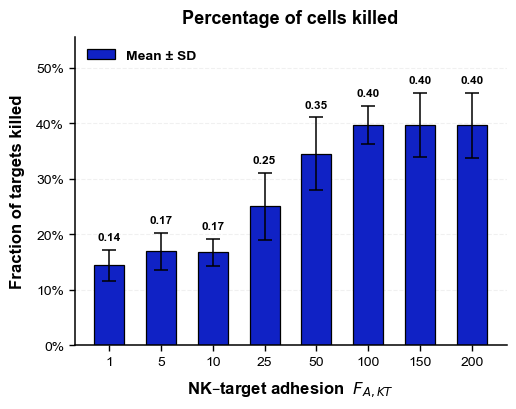

Saved: 2.1a_plot_FAKT_killing_efficiency.png


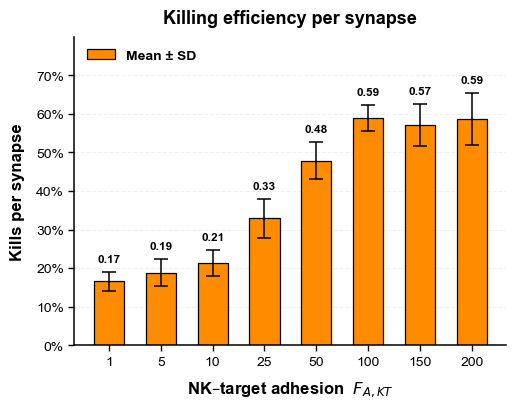

Saved: 2.1b_plot_FAKT_kills_per_synapse.png


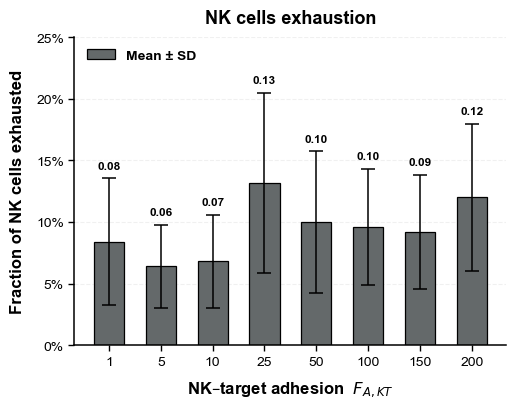

Saved: 2.1c_plot_FAKT_exhaustion.png


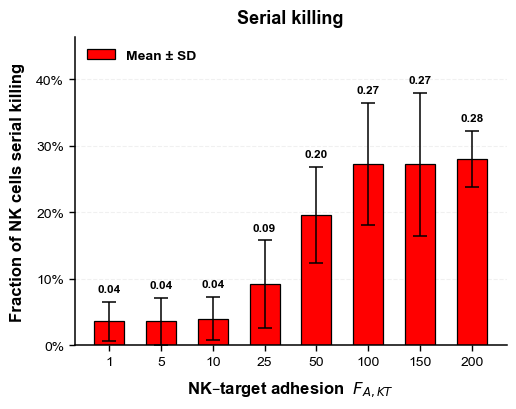

Saved: 2.1d_plot_FAKT_serial_killing.png


In [6]:
panels = [
    (
        "kill_frac",
        "Fraction of targets killed",
        "Percentage of cells killed",
        True,
        "2.1a_plot_FAKT_killing_efficiency.png",
    ),
    (
        "kills_per_synapse",
        "Kills per synapse",
        "Killing efficiency per synapse",
        True,
        "2.1b_plot_FAKT_kills_per_synapse.png",
    ),
    (
        "frac_exhausted",
        "Fraction of NK cells exhausted",
        "NK cells exhaustion",
        True,
        "2.1c_plot_FAKT_exhaustion.png",
    ),
    (
        "frac_serial",
        "Fraction of NK cells serial killing",
        "Serial killing",
        True,
        "2.1d_plot_FAKT_serial_killing.png",
    ),
]

for col, ylabel, title, pct, filename in panels:

    fig, ax = plt.subplots(figsize=(5.4, 4.6), facecolor="none")
    fig.subplots_adjust(left=0.16, right=0.96, top=0.84, bottom=0.17)

    ax.set_facecolor("none")

    means, stds = _agg(col)

    _bar(ax, means, stds, COLOURS[col], "Mean ± SD")

    ax.set_ylabel(ylabel, fontweight="bold", labelpad=8)
    ax.set_title(title, fontweight="bold", pad=10)

    if pct:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))

    _style(ax)

    plt.savefig(filename, transparent=True, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {filename}")

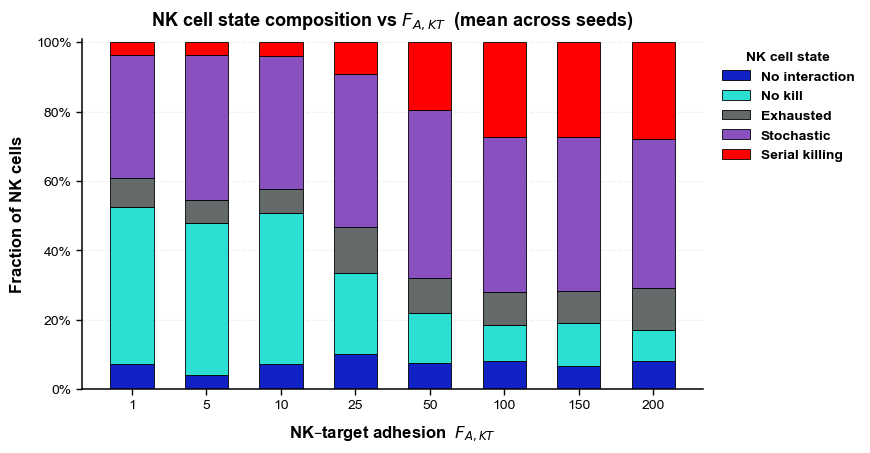

Saved: plot_FAKT_state_composition.png


In [15]:
state_col_map = {
    "no_interaction": "n_no_interaction",
    "no_kill":        "n_no_kill",
    "exhausted":      "n_exhausted",
    "stochastic":     "n_stochastic",
    "serial_kill":    "n_serial_kill",
}
 
n_killer_cols = list(state_col_map.values())
hpc["n_killers_total"] = hpc[n_killer_cols].sum(axis=1)
 
fracs = {}
for state, col in state_col_map.items():
    hpc[f"_frac_{state}"] = hpc[col] / hpc["n_killers_total"]
    fracs[state] = hpc.groupby("F_A_KT")[f"_frac_{state}"].mean().reindex(F_vals).values
 
fig, ax = plt.subplots(figsize=(9, 4.8), facecolor="none")
ax.set_facecolor("none")
fig.subplots_adjust(left=0.09, right=0.78, top=0.88, bottom=0.15)
 
bottoms = np.zeros(len(F_vals))
for state in STATE_ORDER:
    ax.bar(
        x, fracs[state],
        bottom=bottoms,
        color=STATE_COLOURS[state],
        label=STATE_LABELS[state],
        width=0.58,
        edgecolor="black",
        linewidth=0.6,
        zorder=2,
    )
    bottoms += fracs[state]
 
ax.set_ylim(0, 1.01)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("Fraction of NK cells", fontweight="bold", labelpad=8)
ax.set_xlabel(r"NK–target adhesion  $F_{A,KT}$", fontweight="bold", labelpad=8)
ax.set_title(
    r"NK cell state composition vs $F_{A,KT}$  (mean across seeds)",
    fontweight="bold", pad=10,
)
_style(ax)
 
legend = ax.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1.0),
    frameon=False, fontsize=10,
    title="NK cell state", title_fontsize=10,
)
for t in legend.get_texts():
    t.set_fontweight("bold")
legend.get_title().set_fontweight("bold")
 
plt.savefig("plot_FAKT_state_composition.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_FAKT_state_composition.png")

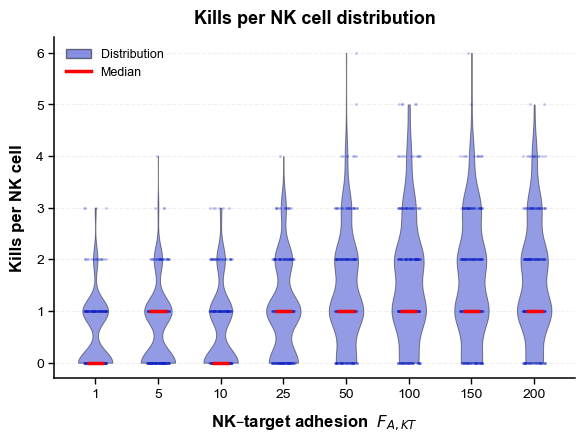

Saved: 2.1e_plot_FAKT_kills_per_NK_distribution.png


In [16]:


fig, ax = plt.subplots(figsize=(6.2, 4.8), facecolor="none")
fig.subplots_adjust(left=0.12, right=0.96, top=0.86, bottom=0.15)
ax.set_facecolor("none")

kpk_groups = [kr[kr["F_A_KT"] == f]["kills_per_killer"].values for f in F_vals]

parts = ax.violinplot(
    kpk_groups,
    positions=x,
    widths=0.55,
    showmedians=True,
    showextrema=False,
)

for pc in parts["bodies"]:
    pc.set_facecolor("#1022C5")
    pc.set_alpha(0.45)
    pc.set_edgecolor("black")
    pc.set_linewidth(0.7)
    pc.set_zorder(2)

# median line
parts["cmedians"].set_color("#FF0000")
parts["cmedians"].set_linewidth(2.5)
parts["cmedians"].set_zorder(5)

rng = np.random.default_rng(0)
for i, f in enumerate(F_vals):
    vals = kr[kr["F_A_KT"] == f]["kills_per_killer"].values
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    ax.scatter(
        i + jitter,
        vals,
        s=4,
        color="#1022C5",
        alpha=0.25,
        linewidths=0,
        zorder=3,
    )

ax.set_ylabel("Kills per NK cell", fontweight="bold", labelpad=8)
ax.set_title("Kills per NK cell distribution", fontweight="bold", pad=10)
_style(ax)

ax.legend(
    handles=[
        Patch(facecolor="#1022C5", alpha=0.5, edgecolor="black", label="Distribution"),
        Line2D([0], [0], color="#FF0000", linewidth=2.5, label="Median"),
    ],
    frameon=False,
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
)

plt.savefig("2.1e_plot_FAKT_kills_per_NK_distribution.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 2.1e_plot_FAKT_kills_per_NK_distribution.png")

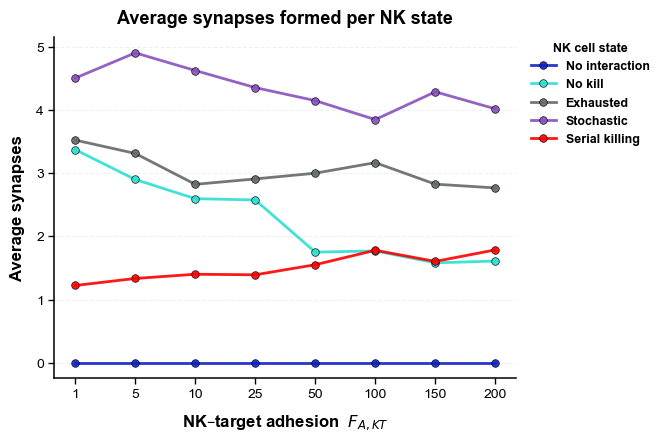

Saved: 2.1f_plot_FAKT_average_synapses_per_state.png


In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 4.8), facecolor="none")
fig.subplots_adjust(left=0.12, right=0.78, top=0.86, bottom=0.15)
ax.set_facecolor("none")

ep_state_means = (
    kr.groupby(["F_A_KT", "state"])["n_episodes"]
    .mean()
    .reset_index()
)

for state in STATE_ORDER:
    sub = (
        ep_state_means[ep_state_means["state"] == state]
        .set_index("F_A_KT")
        .reindex(F_vals)
    )
    ax.plot(
        x,
        sub["n_episodes"].values,
        color=STATE_COLOURS[state],
        label=STATE_LABELS[state],
        linewidth=2.0,
        marker="o",
        markersize=5.5,
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.90,
        zorder=2,
    )

ax.set_ylabel("Average synapses", fontweight="bold", labelpad=8)
ax.set_title("Average synapses formed per NK state", fontweight="bold", pad=10)
_style(ax)

legend = ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    title="NK cell state",
    title_fontsize=9,
    borderaxespad=0,
)

for t in legend.get_texts():
    t.set_fontweight("bold")
legend.get_title().set_fontweight("bold")

plt.savefig("2.1f_plot_FAKT_average_synapses_per_state.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 2.1f_plot_FAKT_average_synapses_per_state.png")

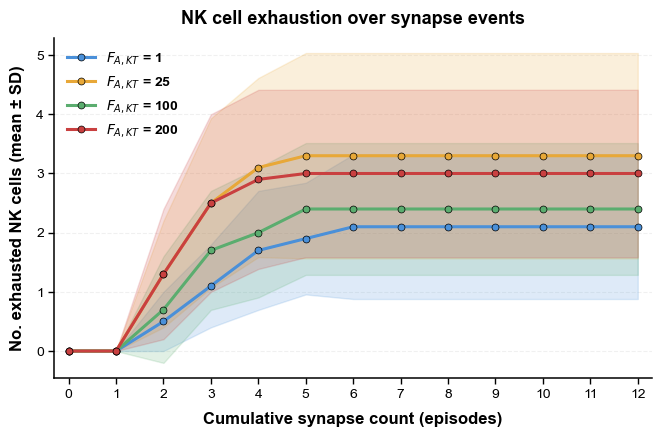

Saved: 2.1g_exhaustion_over_timepoints.png


In [ ]:


SELECTED_FAKTS = [1, 25, 100, 200]

EXHAUSTION_COLOURS = {
    1:   "#4A90D9",
    25:  "#E8A838",
    100: "#5BAD6F",
    200: "#C94040",
}

ep_range = np.arange(0, 13)   # episode bins 0–12
ex = kr[kr["state"] == "exhausted"]

fig, ax = plt.subplots(figsize=(7.2, 4.8), facecolor="none")
fig.subplots_adjust(left=0.13, right=0.96, top=0.86, bottom=0.15)
ax.set_facecolor("none")

for f in SELECTED_FAKTS:
    ex_f  = ex[ex["F_A_KT"] == f]
    seeds = sorted(kr[kr["F_A_KT"] == f]["seed"].unique())

    per_seed = []
    for s in seeds:
        ex_s = ex_f[ex_f["seed"] == s]["n_episodes"].values
        per_seed.append([np.sum(ex_s <= t) for t in ep_range])

    arr  = np.array(per_seed)   # shape: (n_seeds, len(ep_range))
    mean = arr.mean(axis=0)
    sd   = arr.std(axis=0)

    ax.plot(
        ep_range, mean,
        color=EXHAUSTION_COLOURS[f],
        linewidth=2.2,
        marker="o", markersize=5,
        markeredgecolor="black", markeredgewidth=0.5,
        zorder=3,
        label=f"$F_{{A,KT}}$ = {f}",
    )
    ax.fill_between(
        ep_range, mean - sd, mean + sd,
        color=EXHAUSTION_COLOURS[f], alpha=0.18, zorder=2,
    )

ax.set_xlim(-0.3, 12.3)
ax.set_xticks(ep_range)
ax.set_xlabel("Cumulative synapse count (episodes)", fontweight="bold", labelpad=8)
ax.set_ylabel("No. exhausted NK cells (mean ± SD)", fontweight="bold", labelpad=8)
ax.set_title("NK cell exhaustion over synapse events", fontweight="bold", pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)
ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

legend = ax.legend(frameon=False, fontsize=10, loc="upper left")
for t in legend.get_texts():
    t.set_fontweight("bold")

plt.savefig("2.1g_exhaustion_over_timepoints.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 2.1g_exhaustion_over_timepoints.png")

In [ ]:
TOTAL_INITIAL_CAPACITY = 25.0
F_vals = sorted(kr["F_A_KT"].unique())
SIM_DURATION = 25.0

PALETTE = {
    1: "#1f77b4",
    5: "#ff7f0e",
    10: "#2ca02c",
    25: "#d62728",
    50: "#9467bd",
    100: "#8c564b",
    150: "#e377c2",
    200: "#17becf",
}

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


def style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(length=3.5, width=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.15)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(14, 4.6), facecolor="none")
gs = gridspec.GridSpec(
    1,
    3,
    wspace=0.42,
    left=0.07,
    right=0.97,
    top=0.84,
    bottom=0.17,
)


ax0 = fig.add_subplot(gs[0])

ex = kr[kr["state"] == "exhausted"]
ep_range = np.arange(0, 13)

for f in F_vals:
    ex_f = ex[ex["F_A_KT"] == f]
    seeds = sorted(kr[kr["F_A_KT"] == f]["seed"].unique())

    per_seed = []

    for s in seeds:
        ex_s = ex_f[ex_f["seed"] == s]["n_episodes"].values
        per_seed.append([np.sum(ex_s <= t) for t in ep_range])

    arr = np.array(per_seed)
    mean = arr.mean(axis=0)
    sd = arr.std(axis=0)

    ax0.plot(
        ep_range,
        mean,
        color=PALETTE[f],
        linewidth=1.8,
        marker="o",
        markersize=3.5,
        markeredgecolor="black",
        markeredgewidth=0.4,
        zorder=3,
        label=f"$F_{{A,KT}}$={f}",
    )

    ax0.fill_between(
        ep_range,
        mean - sd,
        mean + sd,
        color=PALETTE[f],
        alpha=0.12,
        zorder=2,
    )

ax0.set_xlim(-0.3, 12.3)
ax0.set_xticks(ep_range[::2])
ax0.set_xlabel("Cumulative synapse contacts\n(episodes)", fontweight="bold")
ax0.set_ylabel("No. exhausted NK cells\n(mean ± SD)", fontweight="bold")
ax0.set_title("A   Exhaustion over contacts", fontweight="bold", loc="left", pad=8)
style(ax0)



ax1 = fig.add_subplot(gs[1])

snap_times = sorted(tp["snapshot_time_requested"].unique())

for f in F_vals:
    tp_f = tp[tp["F_A_KT"] == f]

    means = []
    sds = []

    for t in snap_times:
        vals = tp_f[tp_f["snapshot_time_requested"] == t]["cytotoxic_cumul_t"]
        means.append(vals.mean())
        sds.append(vals.std())

    means = np.array(means)
    sds = np.array(sds)

    ax1.plot(
        snap_times,
        means,
        color=PALETTE[f],
        linewidth=1.8,
        marker="o",
        markersize=3.5,
        markeredgecolor="black",
        markeredgewidth=0.4,
        zorder=3,
    )

    ax1.fill_between(
        snap_times,
        means - sds,
        means + sds,
        color=PALETTE[f],
        alpha=0.12,
        zorder=2,
    )

ax1.set_xlabel("Simulation time (h)", fontweight="bold")
ax1.set_ylabel(
    "Cumulative cytotoxic output\n(Δ cell state, mean ± SD)",
    fontweight="bold",
)
ax1.set_title("B   Cytotoxic particle release", fontweight="bold", loc="left", pad=8)
ax1.set_xticks(snap_times)
style(ax1)



ax2 = fig.add_subplot(gs[2])

hpc["killing_rate"] = hpc["kills"] / SIM_DURATION

means_kr = hpc.groupby("F_A_KT")["killing_rate"].mean().reindex(F_vals).values
sds_kr = hpc.groupby("F_A_KT")["killing_rate"].std().reindex(F_vals).values

for i, f in enumerate(F_vals):
    ax2.bar(
        i,
        means_kr[i],
        color=PALETTE[f],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
        width=0.7,
    )

    ax2.errorbar(
        i,
        means_kr[i],
        yerr=sds_kr[i],
        fmt="none",
        color="black",
        capsize=3.5,
        linewidth=1.0,
        zorder=4,
    )

ax2.set_xticks(range(len(F_vals)))
ax2.set_xticklabels([str(f) for f in F_vals], rotation=45, ha="right")
ax2.set_xlabel("$F_{A,KT}$", fontweight="bold")
ax2.set_ylabel("Killing rate (kills h⁻¹)\n(mean ± SD)", fontweight="bold")
ax2.set_title("C   Killing rate vs $F_{A,KT}$", fontweight="bold", loc="left", pad=8)
style(ax2)



legend_elements = [
    Line2D(
        [0],
        [0],
        color=PALETTE[f],
        linewidth=2,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.4,
        label=f"$F_{{A,KT}}$={f}",
    )
    for f in F_vals
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=8,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.52, 1.0),
    columnspacing=0.8,
    handlelength=1.6,
)


plt.savefig(
    "2.1_exhaustion_cytotoxic_killingrate.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight",
)


C:\Users\szonj\AppData\Local\Temp\ipykernel_25724\1371034224.py:238: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(


Saved.


In [ ]:


TOTAL_INITIAL_CAPACITY = 25.0
# ─── Calculate remaining capacity 

tp["capacity_remaining"] = TOTAL_INITIAL_CAPACITY - tp["cytotoxic_cumul_t"]
tp["capacity_remaining"] = tp["capacity_remaining"].clip(lower=0)

snap_times = sorted(tp["snapshot_time_requested"].unique())


fig, ax = plt.subplots(figsize=(7.2, 5.0), facecolor="none")

for f in F_vals:
    tp_f = tp[tp["F_A_KT"] == f]

    means = []
    sds = []

    for t in snap_times:
        vals = tp_f[tp_f["snapshot_time_requested"] == t]["capacity_remaining"]
        means.append(vals.mean())
        sds.append(vals.std())

    means = np.array(means)
    sds = np.array(sds)
    print(f"F_A_KT={f}: means={means}, sds={sds}")

    ax.plot(
        snap_times,
        means,
        color=PALETTE[f],
        linewidth=2.0,
        marker="o",
        markersize=4.2,
        markeredgecolor="black",
        markeredgewidth=0.45,
        label=f"$F_{{A,KT}}$={f}",
        zorder=3,
    )

    ax.fill_between(
        snap_times,
        means - sds,
        means + sds,
        color=PALETTE[f],
        alpha=0.12,
        zorder=2,
    )


ax.set_xlabel("Simulation time (h)", fontweight="bold")
ax.set_ylabel(
    "Total NK cytotoxic capacity remaining\n(mean ± SD)",
    fontweight="bold",
)
ax.set_title(
    "NK cytotoxic capacity depletion over time",
    fontweight="bold",
    pad=12,
)

ax.set_xticks(snap_times)
ax.set_ylim(bottom=20, top=TOTAL_INITIAL_CAPACITY * 1.05)

style(ax)


legend_elements = [
    Line2D(
        [0],
        [0],
        color=PALETTE[f],
        linewidth=2,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.4,
        label=f"$F_{{A,KT}}$={f}",
    )
    for f in F_vals
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=9,
    ncol=2,
    loc="lower left",
)


plt.tight_layout()

plt.savefig(
    "2.1_total_capacity_remaining.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight",
)

print("2.1_total_capacity_remaining.png")

F_A_KT=1: means=[25.         24.41441349 23.5631777  22.93723108 22.33816423 21.74958722], sds=[0.         0.17013711 0.26010415 0.34905087 0.36147354 0.32567999]
F_A_KT=5: means=[25.         24.31294423 23.48323112 22.78892194 22.1506778  21.54821326], sds=[0.         0.15397438 0.25468227 0.31685234 0.29224466 0.30067335]
F_A_KT=10: means=[25.         24.44421366 23.67542047 22.98417769 22.29194905 21.72136951], sds=[0.         0.13825509 0.17516686 0.24306407 0.24025782 0.25315364]
F_A_KT=25: means=[25.         24.19157692 23.38092275 22.66009855 21.92227661 21.32585792], sds=[0.         0.23807254 0.5320582  0.66719179 0.59148511 0.58907259]
F_A_KT=50: means=[25.         24.16220763 23.17875211 22.19585408 21.3547647  20.79683604], sds=[0.         0.32817036 0.57620629 0.58911404 0.62785774 0.57335852]
F_A_KT=100: means=[25.         24.14368185 22.90075962 22.03375231 21.28067988 20.57057329], sds=[0.         0.28891845 0.37365517 0.2950068  0.27681049 0.2882944 ]
F_A_KT=150: means

In [ ]:


tmp = kr.copy()
tmp["is_exhausted"] = (tmp["state"] == "exhausted").astype(int)

summary = (
    tmp.groupby(["F_A_KT", "seed"])["is_exhausted"]
    .sum()
    .reset_index(name="n_exhausted")
)

F_vals = sorted(summary["F_A_KT"].unique())

means = summary.groupby("F_A_KT")["n_exhausted"].mean().reindex(F_vals)
sds   = summary.groupby("F_A_KT")["n_exhausted"].std().reindex(F_vals)

fig, ax = plt.subplots(figsize=(7.2, 5.0), facecolor="none")

for i, f in enumerate(F_vals):
    ax.bar(
        i,
        means.loc[f],
        yerr=sds.loc[f],
        color=PALETTE[f],
        edgecolor="black",
        linewidth=0.7,
        capsize=4,
        zorder=3,
        width=0.7,
    )

ax.set_xticks(range(len(F_vals)))
ax.set_xticklabels([str(f) for f in F_vals], rotation=45, ha="right")
ax.set_xlabel("$F_{A,KT}$", fontweight="bold")
ax.set_ylabel("Final exhausted NK cells\n(mean ± SD)", fontweight="bold")
ax.set_title("Final behavioural exhaustion across $F_{A,KT}$", fontweight="bold", pad=12)

style(ax)
plt.tight_layout()
plt.savefig(
    "2.1_final_exhausted_nk_cells.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight",
)


In [ ]:

kr_summary = (
    kr.groupby(["F_A_KT", "seed"], as_index=False)
      .agg(
          n_exhausted_final=("state", lambda x: (x == "exhausted").sum()),
          final_kills_from_kr=("n_kill_episodes", "sum")
      )
)

tp_est = tp.merge(kr_summary, on=["F_A_KT", "seed"], how="left")

tp_est["exhausted_per_kill"] = np.where(
    tp_est["final_kills_from_kr"] > 0,
    tp_est["n_exhausted_final"] / tp_est["final_kills_from_kr"],
    0.0
)
tp_est["n_exhausted_est_t"] = tp_est["n_kills_t"] * tp_est["exhausted_per_kill"]

tp_est["n_exhausted_est_t"] = np.minimum(
    tp_est["n_exhausted_est_t"],
    tp_est["n_exhausted_final"]
)


F_vals = sorted(tp_est["F_A_KT"].unique())

fig, ax = plt.subplots(figsize=(7.2, 5.0), facecolor="none")

for f in F_vals:
    sub = tp_est[tp_est["F_A_KT"] == f].copy()
    time_vals = sorted(sub["snapshot_time_requested"].unique())

    means = []
    sds = []

    for t in time_vals:
        vals = sub[sub["snapshot_time_requested"] == t]["n_exhausted_est_t"]
        means.append(vals.mean())
        sds.append(vals.std())

    means = np.array(means)
    sds = np.array(sds)

    ax.plot(
        time_vals,
        means,
        color=PALETTE[f],
        linewidth=2.0,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.45,
        label=f"$F_{{A,KT}}$={f}",
        zorder=3,
    )

    ax.fill_between(
        time_vals,
        means - sds,
        means + sds,
        color=PALETTE[f],
        alpha=0.12,
        zorder=2,
    )

ax.set_xlabel("Simulation time (h)", fontweight="bold")
ax.set_ylabel("Estimated exhausted NK cells\n(mean ± SD)", fontweight="bold")
ax.set_title("Estimated NK exhaustion over time", fontweight="bold", pad=12)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

style(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
    loc="upper left",
)

plt.tight_layout()
plt.savefig(
    "2.1_final_exhausted_nk_cells.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight",
)